In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

In [2]:
file_path_1 = r"D:\Singapore\Alzheimer\R files\final data_new\imoutations_diff_ks\final_data_imputed_k1.csv"
df = pd.read_csv(file_path_1)

In [3]:
file_path =  r"D:\Singapore\Alzheimer\R files\final data_new\Variable list-11MAY2025.xlsx"
df_Variables = pd.read_excel(file_path)

In [4]:
# Group features based on the "Group" column
demographics = df_Variables[df_Variables['Group'] == 'Demographic']['Predictor'].tolist()
clinical_cognitive = df_Variables[df_Variables['Group'] == 'Clinical/Cognitive']['Predictor'].tolist()
biomarker = df_Variables[df_Variables['Group'] == 'Biomarker']['Predictor'].tolist()
neuroimaging = df_Variables[df_Variables['Group'] == 'Neuroimaging']['Predictor'].tolist()

# Optional: Print or check lists
print("Demographics:", demographics)
print("Clinical/Cognitive:", clinical_cognitive)
print("Biomarker:", biomarker)
print("Neuroimaging:", neuroimaging)

Demographics: ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTRACCAT', 'PTMARRY']
Clinical/Cognitive: ['CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'RAVLT.immediate', 'RAVLT.learning', 'RAVLT.forgetting', 'RAVLT.perc.forgetting', 'LDELTOTAL', 'TRABSCOR', 'FAQ', 'EcogPtTotal', 'MOCA_bl', 'MMSE_bl']
Biomarker: ['FDG', 'AV45', 'ABETA', 'TAU', 'PTAU']
Neuroimaging: ['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV']


In [5]:
group_1 = demographics + clinical_cognitive
group_2 = demographics + biomarker
group_3 = demographics + clinical_cognitive + biomarker
group_4 = neuroimaging

In [6]:
fig_save_dir = r"D:\Singapore\Alzheimer\R files\final data_new\figures\shap"
os.makedirs(fig_save_dir, exist_ok=True)

In [7]:
synthetic_data_1 = pd.read_csv(
    r"D:\Singapore\Alzheimer\R files\final data_new\synthetic_data\TVAE\group_1_3\synthetic_group_1_TVAE_3x.csv"
)


synthetic_data_2 = pd.read_csv(
    r"D:\Singapore\Alzheimer\R files\final data_new\synthetic_data\TVAE\group_2\synthetic_group_2_TVAE_3x.csv"
)


synthetic_data_3 = pd.read_csv(
    r"D:\Singapore\Alzheimer\R files\final data_new\synthetic_data\TVAE\group_1_3\synthetic_group_3_TVAE_3x.csv"
)


synthetic_data_4 = pd.read_csv(
    r"D:\Singapore\Alzheimer\R files\final data_new\synthetic_data\TVAE\group_4\synthetic_group_4_TVAE_3x.csv"
)

In [8]:
target_col = "convert_Within_3Years"



real_data_group = pd.concat(
    [df[group_3], df[target_col]],
    axis=1
)

train_data, test_data = train_test_split(
    real_data_group,
    test_size=0.30,
    random_state=100,
    stratify=real_data_group[target_col]
)

augmented_train = pd.concat(
    [train_data, synthetic_data_3],
    ignore_index=True
)

X_train_aug = augmented_train[group_3]
y_train_aug = augmented_train[target_col]

X_test = test_data[group_3]
y_test = test_data[target_col]

In [9]:
model = RandomForestClassifier(random_state=100, class_weight='balanced')

param_dist = {
    'n_estimators': [150, 200],
    'max_depth': [2, 3],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [6, 8, 10],
    'max_features': ['log2'],
    'bootstrap': [True],
    'max_samples': [0.5, 0.7, 0.9]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=100
)

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    cv=cv,
    scoring='roc_auc',
    refit=True,
    random_state=100
)

search.fit(
    X_train_aug,
    y_train_aug
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...dom_state=100)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True], 'max_depth': [2, 3], 'max_features': ['log2'], 'max_samples': [0.5, 0.7, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22

In [10]:
best_params = search.best_params_

best_model = RandomForestClassifier(

    **best_params,
    random_state=100,
    class_weight='balanced')

best_model.fit(
    X_train_aug,
    y_train_aug
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

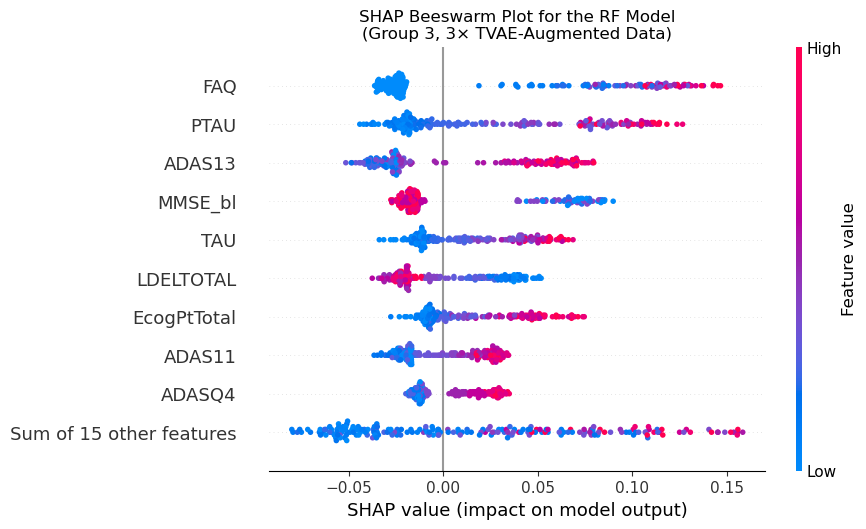

In [11]:
explainer = shap.Explainer(
    best_model,
    X_train_aug
)

shap_values = explainer(
    X_test
)

shap.plots.beeswarm(
    shap_values[:,:,1],
    show = False
)

plt.title(
    "SHAP Beeswarm Plot for the RF Model\n(Group 3, 3× TVAE-Augmented Data)")

plt.savefig(os.path.join(fig_save_dir, f"Beeswarm_Group 3_Real_TVAE_RF.pdf"), dpi=600, bbox_inches="tight")
plt.show()